In [1]:
import numpy as np
import random
import yaml
import os
from deap import gp
from alpine.gp.gpsymbreg import GPSymbolicRegressor
import warnings
import ray
from sympy import symbols, lambdify, sin, sqrt, pprint, latex, cos, tanh
from IPython.display import display, Math
from ControllerComp import V_x, f, x, G, Q, R, safe_divideSR, compute_v_and_v_dot2

from Fitness import fitness
from PredictScoreFuncs import predict, score
import Functions
from SymFunctions import read_expression, DeapSimplifier
from V_Vdot_Calculations import compute_v_and_v_dot

import matplotlib.pyplot as plt

In [2]:
# Define the numerical grid (Domain)
x1_vals = np.linspace(-3, 3, 100)
x2_vals = np.linspace(-3, 3, 100)
X1, X2 = np.meshgrid(x1_vals, x2_vals)

In [3]:
def main():
    yamlfile = "Lyapunov.yaml"
    filename = yamlfile
    with open(filename) as config_file:
        config_file_data = yaml.safe_load(config_file)

    pset = gp.PrimitiveSetTyped(
        "MAIN",
        [
            float, float
        ],
        float,
    )
    
    pset.renameArguments(ARG0="x1", ARG1="x2")
    
    #pset.addPrimitive(one_minus_cos, (float,), float)
    
    #pset.addEphemeralConstant("rand", lambda: random.uniform(-10, 10), float)
    #pset.addTerminal(1, float) 
    
    penalty = config_file_data["gp"]["penalty"]
    common_data = {"penalty": penalty}

    gpsr = GPSymbolicRegressor(
        pset=pset,
        fitness=fitness.remote,
        error_metric=score.remote,
        predict_func=predict.remote,
        common_data=common_data,
        config_file_data=config_file_data,
        print_log=True,
        batch_size=100,
    )

    train_data = Functions.Dataset("true_data", [x1_vals, x2_vals], None)
    gpsr.fit(train_data)

    # Access and save the best individual
    best_expression = gpsr.best  # Save the best expression
    best_fitness = gpsr.train_fit_history[-1]  # Save the best fitness score

    # Write best expression to a file
    with open("best_expression.txt", "w") as file:
        file.write(f"Best Expression:\n{best_expression}\n")
        file.write(f"Best Fitness:\n{best_fitness}\n")

    print("Best Expression and Fitness saved to 'best_expression.txt'.")

    ray.shutdown()


if __name__ == "__main__":
    main()

2025-02-04 16:10:25,786	INFO worker.py:1832 -- Started a local Ray instance. View the dashboard at 127.0.0.1:8265 


Generating initial population(s)...
DONE.
 -= START OF EVOLUTION =- 
Evaluating initial population(s)...
DONE.
   	     	                     fitness                      	              size             
   	     	--------------------------------------------------	-------------------------------
gen	evals	min    	avg        	max      	std       	min	avg   	max	std    
1  	1000 	100.463	6.36958e+11	5.008e+12	1.2079e+12	3  	31.522	83 	22.2783
Best individuals of this generation:
sub(mul(add(x1, x2), add(x1, x2)), sub(add(x1, x1), add(x2, x2)))
2  	1000 	1.3906 	4.612e+08  	7.2e+10  	4.17148e+09	3  	34.242	89 	24.4183
Best individuals of this generation:
mul(add(sub(x2, x1), add(add(x2, x2), x2)), add(add(x2, x2), add(x1, x1)))
3  	1000 	1.2747 	6.00029e+06	1e+08    	2.37486e+07	3  	19.192	77 	14.9528
Best individuals of this generation:
add(add(mul(add(x2, x1), sub(x1, x1)), add(mul(x1, x2), add(x2, x1))), sub(mul(add(x1, add(add(x2, x1), add(x2, x2))), add(x1, x2)), sub(add(x1, x1), sub

In [4]:
expression = read_expression("best_expression.txt") #+ '+ 73'#'0.01875 * x2**2 + 0.73575 * (1 - cos(x1))'
#read_expression("best_expression.txt") #+ '+ 73'
simplified_expr = DeapSimplifier(expression)
display(Math(latex(simplified_expr)))

Original Expression: add(add(mul(add(x2, x1), sub(x1, x1)), add(mul(x1, x2), add(x2, x1))), sub(mul(add(x1, add(add(x2, x1), add(x2, x2))), add(x1, x2)), sub(add(x1, x1), sub(x1, x2))))
Simplified Expression: x1*x2 + (x1 + x2)*(2*x1 + 3*x2)


<IPython.core.display.Math object>

In [5]:
# Define symbolic variables
x1, x2 = symbols('x1 x2')
V_func = lambdify((x1, x2), simplified_expr, modules='numpy')
V_vals = V_func(X1, X2)

In [6]:
V_vals, V_grad_mag, V_dot_vals, lambda_vals, u_vals, u_vals2, u_mag = compute_v_and_v_dot(V_vals, x1_vals, x2_vals)

In [7]:
V_violations = np.count_nonzero(V_vals < 0)
print(V_violations)

Vdot_violations = np.count_nonzero(V_dot_vals > 0)
print(Vdot_violations)

2360
102


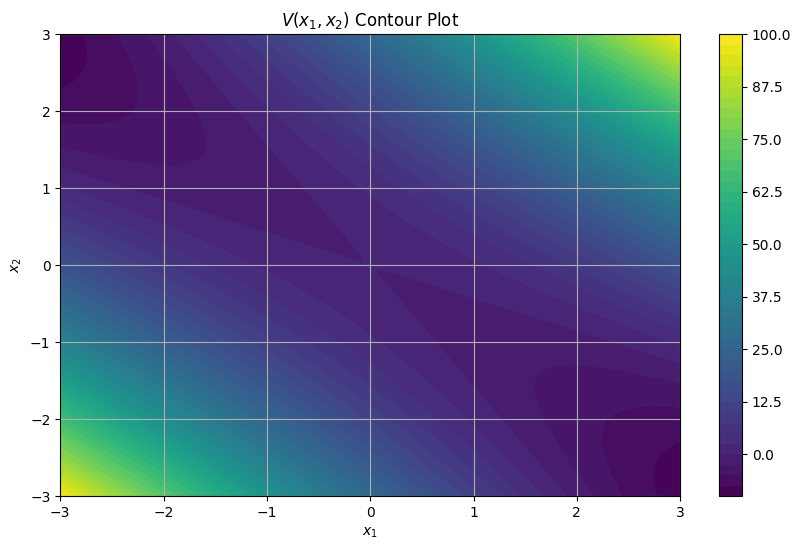

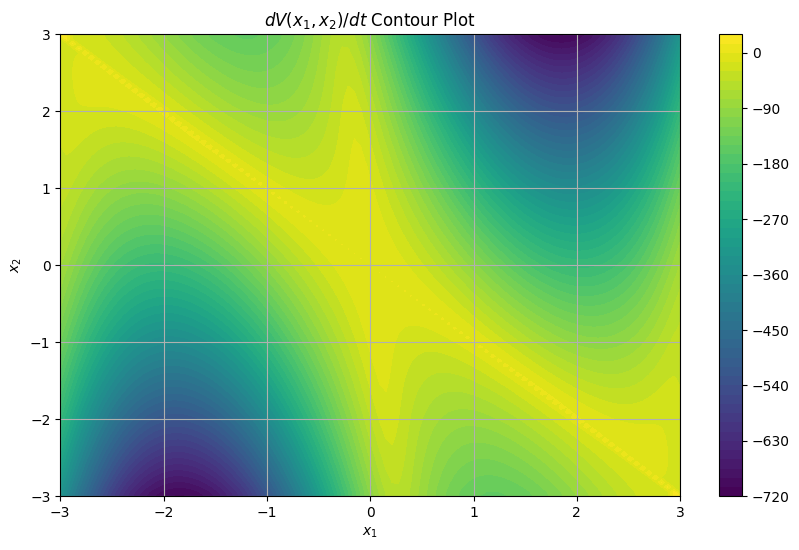

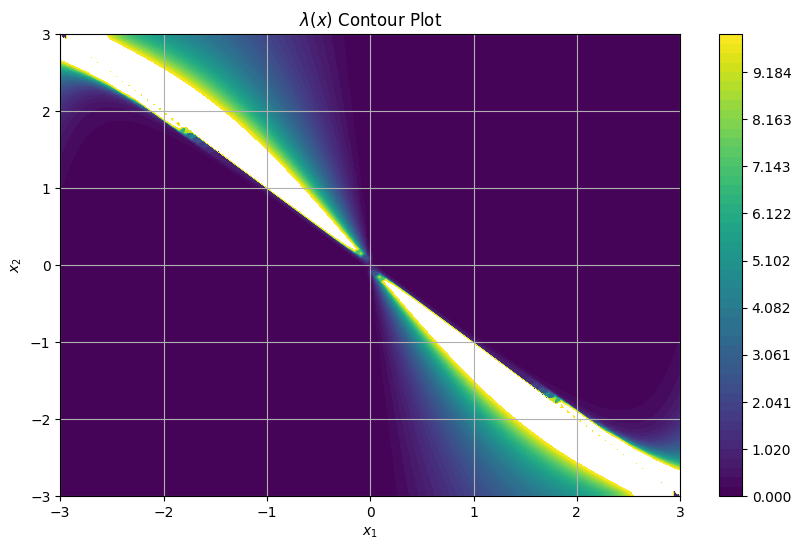

mean value of lambda:
4.14152017746173


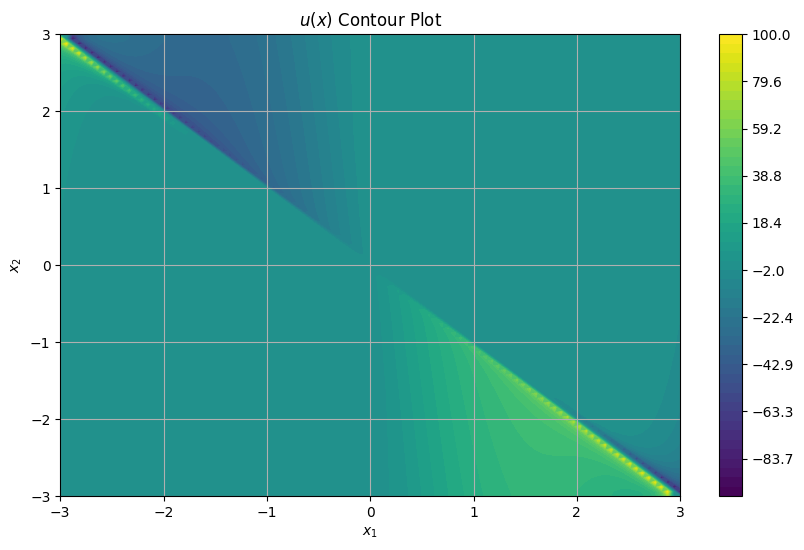

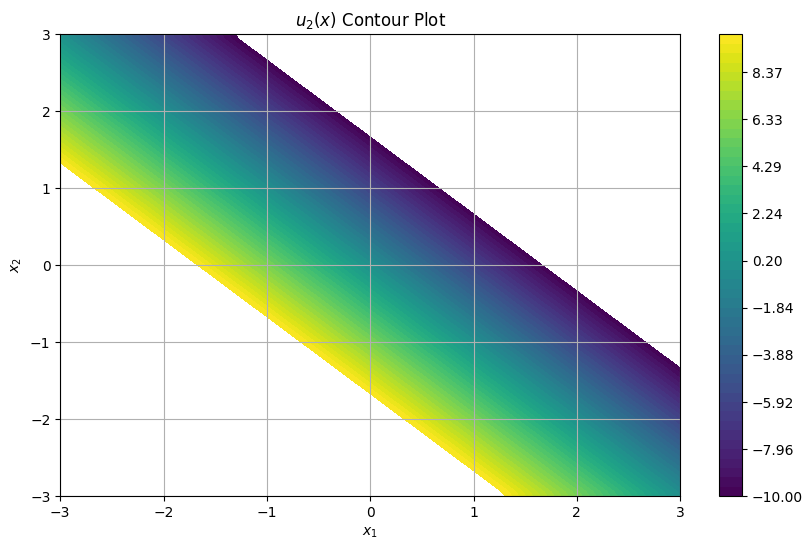

In [8]:
import matplotlib.pyplot as plt

X1 = x1_vals
X2 = x2_vals

# Plot V(x1, x2)
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$V(x_1, x_2)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of V_x1
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, V_dot_vals, levels=50, cmap='viridis')
plt.colorbar(contour)
plt.title(r"$d V(x_1, x_2) / dt$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

# Plot the contour of lambda_x
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, lambda_vals, levels=np.linspace(0, 10, 50), cmap='viridis')
plt.colorbar(contour)
plt.title(r"$\lambda(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

print('mean value of lambda:')
print(np.mean(lambda_vals))

# Plot the contour of u
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals, levels=np.linspace(-100, 100, 50), cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()

# Plot the contour of u
plt.figure(figsize=(10, 6))
contour = plt.contourf(X1, X2, u_vals2, levels=np.linspace(-10, 10, 50), cmap='viridis')
plt.colorbar(contour)
plt.title(r"$u_2(x)$ Contour Plot")
plt.xlabel(r"$x_1$")
plt.ylabel(r"$x_2$")
plt.grid()
plt.show()

In [9]:
V = simplified_expr
x1, x2 = symbols('x1 x2')
V_grad = V_x(V, x1, x2)
x_vector = x(x1, x2)
f_vector = f(x1, x2)
G_matrix = G(x1, x2)
Q_matrix = Q(x1, x2)
R_matrix = R(x1, x2)

V_func, V_dot_func, lambda_func, u_func, u_func2, u_mag = compute_v_and_v_dot2(V)

print(u_func)
u_func

(-6*x1 - 6*x2)*(sqrt((6*x1 + 6*x2)**2*(x1**2 + x2**2) + (x2*(4*x1 + 6*x2) + (6*x1 + 6*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(4*x1 + 6*x2) + (6*x1 + 6*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(6*x1 + 6*x2)**2)


(-6*x1 - 6*x2)*(sqrt((6*x1 + 6*x2)**2*(x1**2 + x2**2) + (x2*(4*x1 + 6*x2) + (6*x1 + 6*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(4*x1 + 6*x2) + (6*x1 + 6*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(6*x1 + 6*x2)**2)

In [10]:
from sympy import symbols, Function, Matrix, Eq, dsolve
from SystemDynamics import f, G, Q, R
from NumSol import NumSol
import matplotlib.pyplot as plt

In [11]:
x1, x2 = symbols('x1 x2')

from sympy import symbols, lambdify, diff, Matrix, sin, cos, exp, log, sqrt, tanh

#u_func = -0.025467670686794*x1 - 0.19026288312708*x2
#u_func = 20 * tanh(-23.28 * x1 + -5.27 * x2)
#u_func = (-73*x1 - 40*x2)*(sqrt((73*x1 + 40*x2)**2*(x1**2 + x2**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(126*x1 + 73*x2) + (73*x1 + 40*x2)*(0.666666666666667*x2 - 19.62*sin(x1)))/(73*x1 + 40*x2)**2)
#u_func = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)

T = 2
x1_0, x2_0 = -1, 1
#t_vals, x1_vals, x2_vals = NumSol(u_func, T, x1_0, x2_0)

In [ ]:
u_func_LQR = -0.025467670686794*x1 - 0.19026288312708*x2
t_vals_L, x1_vals_L, x2_vals_L = NumSol(u_func_LQR, T, x1_0, x2_0)

u_func_NN = 20 * tanh(-23.28 * x1  -5.27 * x2)
t_vals_N, x1_vals_N, x2_vals_N = NumSol(u_func_NN, T, x1_0, x2_0)

#u_func_CLF = (-68*x1 - 144*x2)*(sqrt((68*x1 + 144*x2)**2*(x1**2 + x2**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))**2) + (x2*(32*x1 + 68*x2) + (68*x1 + 144*x2)*(-2.66666666666667*x2 - 19.62*sin(x1)))/(68*x1 + 144*x2)**2)
u_func_CLF = u_func
t_vals_C, x1_vals_C, x2_vals_C = NumSol(u_func_CLF, T, x1_0, x2_0)


In [ ]:
# Plot the solution
plt.figure(figsize=(10, 6))

plt.plot(t_vals_L, x1_vals_L, label="x1(t) - LQR", color="red", linestyle='--')
plt.plot(t_vals_L, x2_vals_L, label="x2(t) - LQR", color="orange", linestyle='--')

plt.plot(t_vals_N, x1_vals_N, label="x1(t) - NN", color="red", linestyle=':')
plt.plot(t_vals_N, x2_vals_N, label="x2(t) - NN", color="orange", linestyle=':')

plt.plot(t_vals_C, x1_vals_C, label="x1(t) - CLF", color="red")
plt.plot(t_vals_C, x2_vals_C, label="x2(t) - CLF", color="orange")
'''
plt.plot(time[0:10], x_list[0:10, 0], label="x1(t) - MCP", color="red", linestyle='-.')
plt.plot(time[0:10], x_list[0:10, 1], label="x2(t) - MPC", color="orange", linestyle='-.')
'''
plt.xlabel("Time (t)")
plt.ylabel("State Variables")
plt.legend()
plt.title("Numerical Solution of the Dynamical System")
plt.grid()
plt.show()


# Plot the 2D trajectory (state space path)
plt.figure(figsize=(10, 6))

plt.plot(x1_vals_L, x2_vals_L, label="Path in State Space - LQR", color="purple")
plt.plot(x1_vals_N, x2_vals_N, label="Path in State Space - NN", color="red")
plt.plot( x1_vals_C, x2_vals_C, label="Path in State Space - CLF", color="green")
'''
plt.plot(x_list[:, 0], x_list[:, 1], label="Path in State Space - MPC", color="b")
'''
plt.scatter(x1_0, x2_0, color="green", label="Start", zorder=5)  # Start point
plt.scatter(0, 0, color="red", label="End", zorder=5)  # End point

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("2D Trajectory in State Space (x1 vs x2)")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from CostFunction import calculate_cost

# Calculate the cost
cost_LQR, cost_LQR1, cost_LQR2 = calculate_cost(t_vals_L, x1_vals_L, x2_vals_L, u_func_LQR, 0)
print("Total cost for LQR:", cost_LQR[0][0], cost_LQR1, cost_LQR2[0][0])

cost_NN, cost_NN1, cost_NN2 = calculate_cost(t_vals_N, x1_vals_N, x2_vals_N, u_func_NN, 0)
print("Total cost for NN:", cost_NN[0][0], cost_NN1, cost_NN2[0][0])

cost_CLF, cost_CLF1, cost_CLF2 = calculate_cost(t_vals_C, x1_vals_C, x2_vals_C, u_func_CLF, 0)
print("Total cost for CLF:", cost_CLF[0][0], cost_CLF1, cost_CLF2[0][0])

In [ ]:
from sympy import simplify

In [ ]:
simplify(u_func_CLF)

In [ ]:
import numpy as np
import do_mpc
from casadi import *
from do_mpc.model import Model
from do_mpc.controller import MPC
from do_mpc.simulator import Simulator
import matplotlib.pyplot as plt

# Create the model
model_type = 'continuous'  # Continuous-time model
model = Model(model_type)

# Define state variables
x1 = model.set_variable('_x', 'x1')  # Position (angle)
x2 = model.set_variable('_x', 'x2')  # Velocity

# Define control input
u = model.set_variable('_u', 'u')

# Define system parameters
g, l, b, m = 9.81, 0.5, 0.1, 0.15
A, B = -g / l, -b / (m * l**2)

# Define nonlinear system dynamics
f1 = x2
#f2 = A * sin(x1) + B * x2 + u  # Nonlinear pendulum equation with control
f2 = -x1 * (3.14/2  + arctan(5 * x1)) - (5 * x1**2 / (2 * (1 + 25 * x1**2))) + 4 * x2 + 3 * u
    

# Set right-hand side (RHS) of system equations
model.set_rhs('x1', f1)
model.set_rhs('x2', f2)

# Finalize model
model.setup()

In [ ]:
mpc = MPC(model)

t_step = 0.5
# Set time step and prediction horizon
mpc.set_param(n_horizon=20, t_step=t_step)

# Define cost function weights
Q = np.diag([1, 1])  # State cost matrix
R = np.diag([0.1])   # Control cost

mpc.set_objective(
    lterm= Q[0, 0] * x1**2 + Q[1, 1] * x2**2 + R[0, 0] * u**2,  # Running cost
    mterm= Q[0, 0] * x1**2 + Q[1, 1] * x2**2  # Terminal cost (optional)
)

mpc.set_rterm(
    u=0.1  # Adjust this value to balance responsiveness and smoothness
)

# Input constraints (control effort limits)
mpc.bounds['lower', '_u', 'u'] = -10
mpc.bounds['upper', '_u', 'u'] = 10

# Setup optimizer
mpc.setup()

In [ ]:
# Create simulator
simulator = Simulator(model)
simulator.set_param(t_step=t_step)
simulator.setup()

# Set initial condition
x0 = np.array([-1, 1])  # Initial angle and velocity
mpc.x0 = x0
simulator.x0 = x0

# Simulate for 100 steps
n_steps = 100
u_list = []
cost_list = [] 
x_list = [x0]

for i in range(n_steps):
    u_cmd = mpc.make_step(x0)  # Solve MPC problem
    x_next = simulator.make_step(u_cmd)  # Simulate system
    u_list.append(u_cmd)

    cost_value = Q[0, 0] * x0[0]**2 + Q[1, 1] * x0[1]**2 + R[0, 0] * u_cmd[0]**2
    cost_list.append(cost_value)

    x_list.append(x_next)
    x0 = x_next  # Update state

In [ ]:
# Convert results to NumPy array
x_list = np.array([np.array(x).flatten() for x in x_list])

time = np.arange(n_steps + 1) * 0.5  # Multiply by t_step

plt.figure(figsize=(10, 4))
plt.plot(time, x_list[:, 0], label='Angle (rad)')
plt.plot(time, x_list[:, 1], label='Velocity (rad/s)')
plt.xlabel("Time (s)")  
plt.ylabel("State Values")
plt.legend()
plt.grid()
plt.show()


# Plot results
plt.figure(figsize=(10, 4))
plt.plot(x_list[:, 0], x_list[:, 1], label='Angle (rad)')
plt.xlabel("Time Step")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Create time vector
time = np.arange(n_steps) * 0.5  # Multiply by t_step

plt.figure(figsize=(10, 4))
plt.plot(time, cost_list, label="Cost Function")
plt.xlabel("Time (s)")
plt.ylabel("Cost Value")
plt.legend()
plt.grid()
plt.show()

In [ ]:
cost_list[10]